# Phase 1, Experiment 1.4 — PCA on ICT block, applied to the hurdle

The 1.2 hurdle (LR + Ridge α=1) is the Phase 1 winner from the structured-zero-inflation track at R² = 0.6386. The progress report's correlation heatmap showed the ICT block (lag1/roll3 versions of influence, creativity, threat, ict_index, bps, minutes — 12 columns) is heavily collinear, with many pairwise correlations above 0.7. PCA is applied only to those 12 features; the rest of the feature set (`BASE_PREKICKOFF`, `POSITION`, `XP`, `OTHER_LAGS`) is left untouched.

PCA scope: fit on `train` ICT_BLOCK only, applied to both hurdle stages identically. Same components everywhere — the principal axes describe player playing-style structure (likely "involvement/floor" and "attacking threat"), not stage-specific transformations.

Honest expectation: PCA preserves performance with fewer features. A neutral result is the valid writeup outcome — Ridge already handles collinearity well, so we shouldn't expect a performance gain.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, r2_score, roc_auc_score, accuracy_score, brier_score_loss
)

sys.path.insert(0, str(Path.cwd()))
from src.config import PROCESSED_PATH, get_feature_group, get_splits

pd.set_option("display.float_format", "{:.4f}".format)
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv(PROCESSED_PATH)
train_mask, val_mask, test_mask = get_splits(df)

def feature_columns(groups):
    cols = []
    for g in groups:
        cols.extend(get_feature_group(g))
    return cols


def evaluate(y_true, y_pred, positions=None):
    out = {"r2": r2_score(y_true, y_pred), "mae": mean_absolute_error(y_true, y_pred)}
    if positions is not None:
        for pos in ["GK", "DEF", "MID", "FWD"]:
            m = positions == pos
            if m.sum():
                out[f"mae_{pos}"] = mean_absolute_error(y_true[m], y_pred[m])
    return out


# Splits & targets
y_train = df.loc[train_mask, "total_points"].values
y_val = df.loc[val_mask, "total_points"].values
val_positions = df.loc[val_mask, "position"].values
y_train_play = df.loc[train_mask, "played_any"].values

played_train_mask = train_mask & (df["played_any"] == 1)
y_train_played_pts = df.loc[played_train_mask, "total_points"].values

# Feature group split: ICT goes through PCA, the rest stays raw
ICT_COLS = get_feature_group("ICT_BLOCK")
NON_ICT_GROUPS = ["BASE_PREKICKOFF", "POSITION", "XP", "OTHER_LAGS"]
NON_ICT_COLS = feature_columns(NON_ICT_GROUPS)
print(f"ICT cols ({len(ICT_COLS)}): {ICT_COLS}")
print(f"Non-ICT cols ({len(NON_ICT_COLS)}): {NON_ICT_COLS}")

ICT cols (12): ['influence_lag1', 'influence_roll3', 'creativity_lag1', 'creativity_roll3', 'threat_lag1', 'threat_roll3', 'ict_index_lag1', 'ict_index_roll3', 'bps_lag1', 'bps_roll3', 'minutes_lag1', 'minutes_roll3']
Non-ICT cols (33): ['was_home', 'opponent_team', 'value', 'selected', 'transfers_in', 'transfers_out', 'transfers_balance', 'is_dgw', 'n_fixtures', 'gws_played', 'pos_DEF', 'pos_FWD', 'pos_GK', 'pos_MID', 'xP', 'total_points_lag1', 'total_points_roll3', 'goals_scored_lag1', 'goals_scored_roll3', 'assists_lag1', 'assists_roll3', 'clean_sheets_lag1', 'clean_sheets_roll3', 'goals_conceded_lag1', 'goals_conceded_roll3', 'bonus_lag1', 'bonus_roll3', 'saves_lag1', 'saves_roll3', 'yellow_cards_lag1', 'yellow_cards_roll3', 'red_cards_lag1', 'red_cards_roll3']


## Fit PCA on train ICT block

Standardize the 12 ICT features on train only, fit PCA on that. Examine the scree (explained variance ratio per component) and pick `n_components` from the plot rather than a fixed % threshold. PC1 and PC2 loadings are inspected to give the components an interpretable meaning.

In [3]:
ict_scaler = StandardScaler().fit(df.loc[train_mask, ICT_COLS].values)
ICT_train_std = ict_scaler.transform(df.loc[train_mask, ICT_COLS].values)
ICT_val_std = ict_scaler.transform(df.loc[val_mask, ICT_COLS].values)
ICT_played_train_std = ict_scaler.transform(df.loc[played_train_mask, ICT_COLS].values)

pca_full = PCA().fit(ICT_train_std)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

print("Component | EVR    | Cumulative")
for i, (e, c) in enumerate(zip(evr, cum), 1):
    print(f"  PC{i:2d}    | {e:.4f} | {c:.4f}")

Component | EVR    | Cumulative
  PC 1    | 0.6973 | 0.6973
  PC 2    | 0.1025 | 0.7998
  PC 3    | 0.0686 | 0.8684
  PC 4    | 0.0626 | 0.9310
  PC 5    | 0.0299 | 0.9609
  PC 6    | 0.0114 | 0.9723
  PC 7    | 0.0109 | 0.9832
  PC 8    | 0.0096 | 0.9928
  PC 9    | 0.0052 | 0.9980
  PC10    | 0.0020 | 1.0000
  PC11    | 0.0000 | 1.0000
  PC12    | 0.0000 | 1.0000


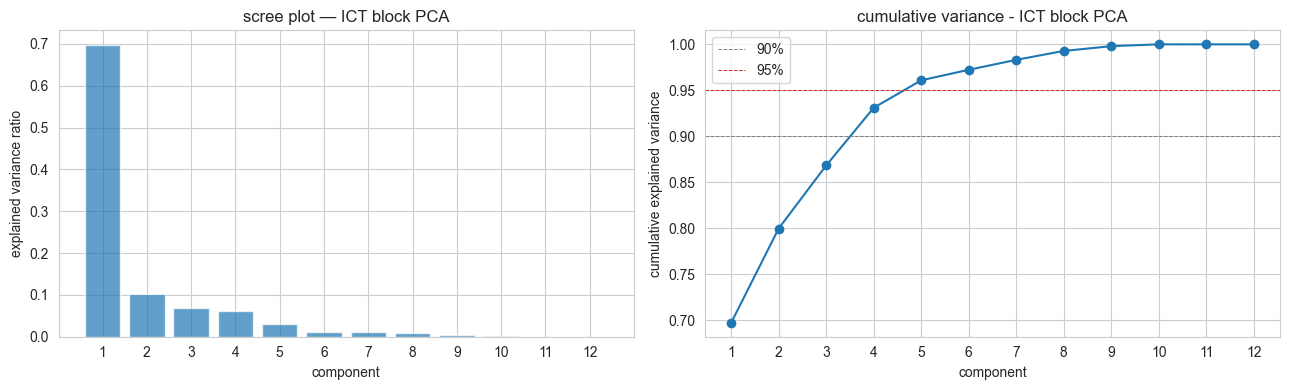

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(evr) + 1), evr, color="tab:blue", alpha=0.7)
axes[0].set_xlabel("component")
axes[0].set_ylabel("explained variance ratio")
axes[0].set_title("scree plot — ICT block PCA")
axes[0].set_xticks(range(1, len(evr) + 1))

axes[1].plot(range(1, len(evr) + 1), cum, marker="o")
axes[1].axhline(0.90, linestyle="--", color="tab:gray", linewidth=0.7, label="90%")
axes[1].axhline(0.95, linestyle="--", color="tab:red", linewidth=0.7, label="95%")
axes[1].set_xlabel("component")
axes[1].set_ylabel("cumulative explained variance")
axes[1].set_title("cumulative variance - ICT block PCA")
axes[1].set_xticks(range(1, len(evr) + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

## Pick n_components from the scree

Inspect the bar plot — look for the elbow where additional components stop adding meaningful variance. Common patterns: a clear two-component story (PC1 dominates, PC2 secondary, then a flat tail) suggests n=2; a more gradual decline with a clear knee at PC3 or PC4 suggests that. Set `n_components` below based on what you see, then proceed.

In [5]:
# Pick the smallest n where adding one more component contributes < 5% additional variance
# AND the remaining components are roughly flat in size. This is the 'elbow' heuristic.
# Override n_components manually if the scree plot disagrees.
n_components = int(np.searchsorted(cum, 0.95) + 1)  # default: 95% threshold as a fallback
print(f"default n_components (95% variance): {n_components}")
print(f"if scree plot suggests a clearer elbow at a different n, override here.")
# Manual override (uncomment + set if needed):
# n_components = 4

default n_components (95% variance): 5
if scree plot suggests a clearer elbow at a different n, override here.


## Inspect PC1 and PC2 loadings

Loadings tell us what each component represents in terms of the original 12 ICT features. Strong positive loadings on `minutes_*` and `bps_*` suggest involvement/floor. Strong loadings on `threat_*`, `creativity_*`, `influence_*` suggest attacking output. Verify rather than assume.

Loadings (PC1-4):
                    PC1     PC2     PC3     PC4
influence_lag1   0.2920 -0.1980 -0.3760  0.2670
influence_roll3  0.3090 -0.2340  0.0380 -0.2500
creativity_lag1  0.2520  0.2680  0.3490  0.5570
creativity_roll3 0.2670  0.2480  0.5560  0.1290
threat_lag1      0.2460  0.4500 -0.4610 -0.0980
threat_roll3     0.2590  0.4180 -0.1040 -0.4640
ict_index_lag1   0.3180  0.2020 -0.2350  0.2680
ict_index_roll3  0.3240  0.1620  0.1630 -0.2500
bps_lag1         0.2920 -0.2820 -0.2580  0.2900
bps_roll3        0.3050 -0.3090  0.1120 -0.1890
minutes_lag1     0.2930 -0.2700  0.0150  0.0310
minutes_roll3    0.2940 -0.2830  0.2060 -0.2440


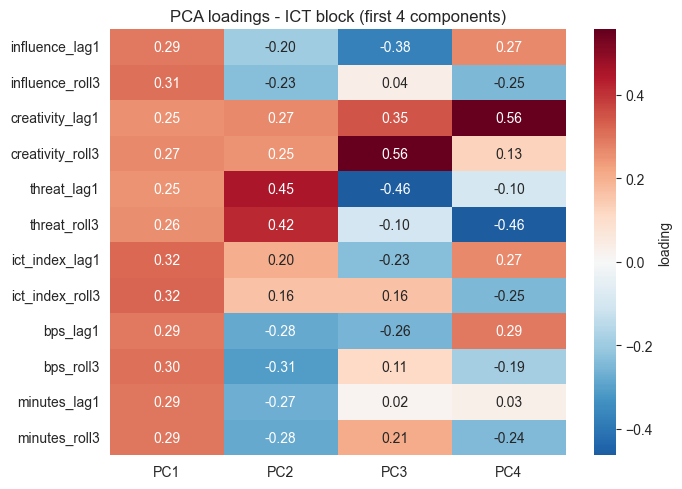

In [14]:
loadings = pd.DataFrame(
    pca_full.components_[:min(4, len(ICT_COLS))].T,
    index=ICT_COLS,
    columns=[f"PC{i+1}" for i in range(min(4, len(ICT_COLS)))],
)
print("Loadings (PC1-4):")
print(loadings.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "loading"})
ax.set_title("PCA loadings - ICT block (first 4 components)")
plt.tight_layout()
plt.show()

## Refit PCA at chosen n_components and transform

Now use the actual PCA with the chosen `n_components`. Apply same fit to all three matrices (full train, val, played-only train).

In [7]:
pca = PCA(n_components=n_components).fit(ICT_train_std)
ICT_train_pca = pca.transform(ICT_train_std)
ICT_val_pca = pca.transform(ICT_val_std)
ICT_played_train_pca = pca.transform(ICT_played_train_std)

print(f"Reduced ICT representation: {ICT_train_pca.shape[1]} components from {len(ICT_COLS)} columns")
print(f"Cumulative variance retained: {cum[n_components-1]:.4f}")

Reduced ICT representation: 5 components from 12 columns
Cumulative variance retained: 0.9609


## Build feature matrices: non-ICT (raw, scaled) + ICT (PCA-transformed)

Two independent scalers — one for the non-ICT block (fit on full train), one already-applied for the ICT block (the standardization that fed into PCA). Concatenate. Stage 1 uses the full-train version; stage 2 uses the played-only-train version with its own non-ICT scaler.

In [8]:
# Stage 1 (full train scope)
non_ict_scaler_s1 = StandardScaler().fit(df.loc[train_mask, NON_ICT_COLS].values)
X_train_s1 = np.hstack([
    non_ict_scaler_s1.transform(df.loc[train_mask, NON_ICT_COLS].values),
    ICT_train_pca,
])
X_val_s1 = np.hstack([
    non_ict_scaler_s1.transform(df.loc[val_mask, NON_ICT_COLS].values),
    ICT_val_pca,
])

# Stage 2 (played-only train scope)
non_ict_scaler_s2 = StandardScaler().fit(df.loc[played_train_mask, NON_ICT_COLS].values)
X_train_s2 = np.hstack([
    non_ict_scaler_s2.transform(df.loc[played_train_mask, NON_ICT_COLS].values),
    ICT_played_train_pca,
])
X_val_s2 = np.hstack([
    non_ict_scaler_s2.transform(df.loc[val_mask, NON_ICT_COLS].values),
    ICT_val_pca,
])

print(f"X_train_s1: {X_train_s1.shape}  (non-ICT: {len(NON_ICT_COLS)} + PCA: {n_components})")
print(f"X_train_s2: {X_train_s2.shape}")

X_train_s1: (46991, 38)  (non-ICT: 33 + PCA: 5)
X_train_s2: (20022, 38)


## Refit hurdle on PCA-transformed features

Same architecture as 1.2: LogisticRegression for stage 1, Ridge α=1 for stage 2. Stage-1 metrics reported separately so we can isolate where any change comes from.

In [9]:
lr_pca = LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE).fit(X_train_s1, y_train_play)
p_play_val_pca = lr_pca.predict_proba(X_val_s1)[:, 1]
y_play_pred_pca = (p_play_val_pca >= 0.5).astype(int)

s1_metrics_pca = {
    "auc": roc_auc_score(df.loc[val_mask, "played_any"].values, p_play_val_pca),
    "accuracy": accuracy_score(df.loc[val_mask, "played_any"].values, y_play_pred_pca),
    "brier": brier_score_loss(df.loc[val_mask, "played_any"].values, p_play_val_pca),
}

ridge_s2_pca = Ridge(alpha=1.0).fit(X_train_s2, y_train_played_pts)
e_pts_val_pca = ridge_s2_pca.predict(X_val_s2)

pred_hurdle_pca = p_play_val_pca * e_pts_val_pca
hurdle_pca_metrics = evaluate(y_val, pred_hurdle_pca, val_positions)

print("Stage 1 (LR with PCA features):")
for k, v in s1_metrics_pca.items():
    print(f"  {k}: {v:.4f}")
print("\nHurdle + PCA (combined, full val):")
for k, v in hurdle_pca_metrics.items():
    print(f"  {k}: {v:.4f}")

Stage 1 (LR with PCA features):
  auc: 0.9465
  accuracy: 0.8819
  brier: 0.0864

Hurdle + PCA (combined, full val):
  r2: 0.6383
  mae: 0.7117
  mae_GK: 0.4445
  mae_DEF: 0.7417
  mae_MID: 0.7480
  mae_FWD: 0.7526


## Refit baseline hurdle (no PCA) for the head-to-head

Reproduce 1.2's hurdle exactly so the comparison sits on the same val rows in one table.

In [10]:
ALL_COLS = NON_ICT_COLS + ICT_COLS

# Stage 1: full train scaler
scaler_s1_raw = StandardScaler().fit(df.loc[train_mask, ALL_COLS].values)
X_train_s1_raw = scaler_s1_raw.transform(df.loc[train_mask, ALL_COLS].values)
X_val_s1_raw = scaler_s1_raw.transform(df.loc[val_mask, ALL_COLS].values)

# Stage 2: played-only train scaler
scaler_s2_raw = StandardScaler().fit(df.loc[played_train_mask, ALL_COLS].values)
X_train_s2_raw = scaler_s2_raw.transform(df.loc[played_train_mask, ALL_COLS].values)
X_val_s2_raw = scaler_s2_raw.transform(df.loc[val_mask, ALL_COLS].values)

lr_raw = LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE).fit(X_train_s1_raw, y_train_play)
p_play_val_raw = lr_raw.predict_proba(X_val_s1_raw)[:, 1]
y_play_pred_raw = (p_play_val_raw >= 0.5).astype(int)

s1_metrics_raw = {
    "auc": roc_auc_score(df.loc[val_mask, "played_any"].values, p_play_val_raw),
    "accuracy": accuracy_score(df.loc[val_mask, "played_any"].values, y_play_pred_raw),
    "brier": brier_score_loss(df.loc[val_mask, "played_any"].values, p_play_val_raw),
}

ridge_s2_raw = Ridge(alpha=1.0).fit(X_train_s2_raw, y_train_played_pts)
e_pts_val_raw = ridge_s2_raw.predict(X_val_s2_raw)

pred_hurdle_raw = p_play_val_raw * e_pts_val_raw
hurdle_raw_metrics = evaluate(y_val, pred_hurdle_raw, val_positions)

print("Stage 1 (LR, raw features — 1.2 reproduction):")
for k, v in s1_metrics_raw.items():
    print(f"  {k}: {v:.4f}")
print("\nHurdle (raw, combined, full val — 1.2 reproduction):")
for k, v in hurdle_raw_metrics.items():
    print(f"  {k}: {v:.4f}")

Stage 1 (LR, raw features — 1.2 reproduction):
  auc: 0.9466
  accuracy: 0.8826
  brier: 0.0863

Hurdle (raw, combined, full val — 1.2 reproduction):
  r2: 0.6386
  mae: 0.7116
  mae_GK: 0.4447
  mae_DEF: 0.7424
  mae_MID: 0.7474
  mae_FWD: 0.7524


## Direct comparison

Stage-1 metrics side-by-side, then full-val combined metrics side-by-side. The interesting numbers are the deltas (PCA - raw); near-zero deltas confirm the "preserved performance with fewer features" story.

In [11]:
s1_compare = pd.DataFrame({"raw (1.2)": s1_metrics_raw, "PCA (1.4)": s1_metrics_pca}).T
print("Stage 1 comparison:")
print(s1_compare)

print("\nHurdle (combined, full val) comparison:")
combined = pd.DataFrame({
    "raw (1.2)": hurdle_raw_metrics,
    "PCA (1.4)": hurdle_pca_metrics,
}).T
combined.loc["Δ (PCA − raw)"] = combined.loc["PCA (1.4)"] - combined.loc["raw (1.2)"]
print(combined)

dim_reduction = len(ICT_COLS) - n_components
print(f"\nFeature count: ICT block reduced from {len(ICT_COLS)} → {n_components} ({dim_reduction} fewer features)")
print(f"Total feature count: {len(ALL_COLS)} → {len(NON_ICT_COLS) + n_components}")

Stage 1 comparison:
             auc  accuracy  brier
raw (1.2) 0.9466    0.8826 0.0863
PCA (1.4) 0.9465    0.8819 0.0864

Hurdle (combined, full val) comparison:
                   r2    mae  mae_GK  mae_DEF  mae_MID  mae_FWD
raw (1.2)      0.6386 0.7116  0.4447   0.7424   0.7474   0.7524
PCA (1.4)      0.6383 0.7117  0.4445   0.7417   0.7480   0.7526
Δ (PCA − raw) -0.0003 0.0001 -0.0002  -0.0006   0.0007   0.0003

Feature count: ICT block reduced from 12 → 5 (7 fewer features)
Total feature count: 45 → 38


## Final Phase 1 results table

In [12]:
flat_ridge = Ridge(alpha=1.0).fit(X_train_s1_raw, y_train)
flat_metrics = evaluate(y_val, flat_ridge.predict(X_val_s1_raw), val_positions)

results = {
    "global mean": evaluate(y_val, np.full_like(y_val, y_train.mean(), dtype=float), val_positions),
    "trailing 3-GW avg": evaluate(y_val, df.loc[val_mask, "total_points_roll3"].values, val_positions),
    "xP passthrough": evaluate(y_val, df.loc[val_mask, "xP"].values, val_positions),
    "Ridge flat (1.1, alpha=1)": flat_metrics,
    "Hurdle (1.2, LR + Ridge alpha=1)": hurdle_raw_metrics,
    "Tweedie (1.3, power=1.1, alpha=0.01)": {"r2": 0.5113, "mae": 0.8619,
                                              "mae_GK": 0.5875, "mae_DEF": 0.9022,
                                              "mae_MID": 0.8790, "mae_FWD": 0.9477},
    f"Hurdle + PCA n={n_components} (1.4)": hurdle_pca_metrics,
}
final = pd.DataFrame(results).T
print(final)

                                          r2    mae  mae_GK  mae_DEF  mae_MID  \
global mean                          -0.0102 1.5528  1.5135   1.5407   1.5454   
trailing 3-GW avg                     0.1139 1.0405  0.6551   1.1193   1.0571   
xP passthrough                        0.5169 0.8129  0.6629   0.8449   0.8271   
Ridge flat (1.1, alpha=1)             0.5989 0.8275  0.6787   0.8451   0.8370   
Hurdle (1.2, LR + Ridge alpha=1)      0.6386 0.7116  0.4447   0.7424   0.7474   
Tweedie (1.3, power=1.1, alpha=0.01)  0.5113 0.8619  0.5875   0.9022   0.8790   
Hurdle + PCA n=5 (1.4)                0.6383 0.7117  0.4445   0.7417   0.7480   

                                      mae_FWD  
global mean                            1.6429  
trailing 3-GW avg                      1.1300  
xP passthrough                         0.8187  
Ridge flat (1.1, alpha=1)              0.8834  
Hurdle (1.2, LR + Ridge alpha=1)       0.7524  
Tweedie (1.3, power=1.1, alpha=0.01)   0.9477  
Hurdle + PCA n=

## Decisions to record for writeup

1. PCA scope: ICT_BLOCK (12 features) only. Non-ICT features (BASE_PREKICKOFF, POSITION, XP, OTHER_LAGS) left raw and standardized normally. Rationale: the progress report's correlation heatmap identified the ICT block as the heavily-collinear sub-group; no theoretical reason to PCA the rest.

2. PCA scaling: standardize the ICT block on train only before fitting PCA. Train/val transformed with the same scaler.

3. PCA shared across hurdle stages: fit once on the full train ICT block, applied identically to stage 1's full-train matrix and stage 2's played-only-train matrix. Rationale: principal axes describe player playing-style structure (player-level, not stage-level); fitting two separate PCAs would give two slightly different "PC1"s with no interpretive benefit.

4. n_components selection: chosen by inspecting the scree plot — see notebook output for the actual value used. The plot drives the decision; the 95% variance fallback is just the script's default if no clearer elbow is identified. Document the actual choice and the reasoning (e.g., "scree showed a clear knee at PC3, additional components added <3% each").

5. Expected outcome: PCA preserves hurdle performance with a smaller ICT representation. A neutral or near-neutral result is the valid finding here — Ridge already handles collinearity through L2, so we did not expect a performance gain. A meaningful drop (>0.005 R²) would mean PCA discarded variance the Ridge model was actually using; investigate before accepting.